In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import datetime
import warnings
warnings.filterwarnings('ignore')

In [25]:
def load_data(file_path):
    # Load the dataset
    df = pd.read_csv(file_path)
    
    # Convert timestamp to datetime
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    
    # Extract time-based features
    df['Hour'] = df['Timestamp'].dt.hour
    df['Day'] = df['Timestamp'].dt.day
    df['Month'] = df['Timestamp'].dt.month
    df['Weekday'] = df['Timestamp'].dt.weekday
    df['Weekend'] = df['Weekday'].isin([5, 6]).astype(int)
    
    # Calculate energy cost
    df['Energy_Cost'] = df['Energy Consumption (kWh)'] * df['Energy Tariff ($/kWh)']
    
    return df

def exploratory_analysis(df):
    # Basic statistics
    print("Dataset shape:", df.shape)
    print("\nData types:")
    print(df.dtypes)
    print("\nSummary statistics:")
    print(df.describe())
    
    # Check for missing values
    print("\nMissing values:")
    print(df.isnull().sum())
    
    # Correlation analysis
    plt.figure(figsize=(12, 10))
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    correlation = df[numeric_cols].corr()
    sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png')
    
    # Plot energy consumption vs environmental factors
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    sns.scatterplot(x='Temperature (°C)', y='Energy Consumption (kWh)', 
                   data=df, ax=axes[0, 0], alpha=0.5)
    axes[0, 0].set_title('Energy Consumption vs Temperature')
    
    sns.scatterplot(x='Humidity (%)', y='Energy Consumption (kWh)', 
                   data=df, ax=axes[0, 1], alpha=0.5)
    axes[0, 1].set_title('Energy Consumption vs Humidity')
    
    sns.scatterplot(x='Building Occupancy', y='Energy Consumption (kWh)', 
                   data=df, ax=axes[1, 0], alpha=0.5)
    axes[1, 0].set_title('Energy Consumption vs Occupancy')
    
    sns.scatterplot(x='Sunlight (W/m²)', y='Energy Consumption (kWh)', 
                   data=df, ax=axes[1, 1], alpha=0.5)
    axes[1, 1].set_title('Energy Consumption vs Sunlight')
    
    plt.tight_layout()
    plt.savefig('energy_vs_factors.png')
    
    # Energy consumption by season
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Season', y='Energy Consumption (kWh)', data=df)
    plt.title('Energy Consumption by Season')
    plt.savefig('energy_by_season.png')
    
    # Energy consumption by hour
    plt.figure(figsize=(12, 6))
    hourly_avg = df.groupby('Hour')['Energy Consumption (kWh)'].mean()
    hourly_avg.plot(kind='line', marker='o')
    plt.title('Average Energy Consumption by Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Energy Consumption (kWh)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('energy_by_hour.png')
    
    return correlation

In [26]:
def multiple_regression_analysis(df):
    # Prepare data for regression
    # Features and target
    features = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 
                'Sunlight (W/m²)', 'Building Occupancy', 'Hour', 'Weekday', 'Weekend', 'Month']
    
    # If Season is categorical, encode it
    if df['Season'].dtype == 'object':
        # One-hot encode Season
        season_dummies = pd.get_dummies(df['Season'], prefix='Season')
        df = pd.concat([df, season_dummies], axis=1)
        # Add season columns to features
        season_cols = season_dummies.columns.tolist()
        features.extend(season_cols)
    
    X = df[features]
    y = df['Energy Consumption (kWh)']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Linear Regression
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)
    lr_mse = mean_squared_error(y_test, lr_pred)
    lr_r2 = r2_score(y_test, lr_pred)
    
    print("Linear Regression Results:")
    print(f"Mean Squared Error: {lr_mse:.4f}")
    print(f"R² Score: {lr_r2:.4f}")
    
    # Feature importance from linear regression
    lr_coef = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': lr_model.coef_
    }).sort_values(by='Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=lr_coef)
    plt.title('Feature Importance (Linear Regression)')
    plt.tight_layout()
    plt.savefig('linear_regression_coefficients.png')
    
    # Random Forest for comparison
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_mse = mean_squared_error(y_test, rf_pred)
    rf_r2 = r2_score(y_test, rf_pred)
    
    print("\nRandom Forest Results:")
    print(f"Mean Squared Error: {rf_mse:.4f}")
    print(f"R² Score: {rf_r2:.4f}")
    
    # Feature importance from random forest
    rf_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=rf_importance)
    plt.title('Feature Importance (Random Forest)')
    plt.tight_layout()
    plt.savefig('random_forest_importance.png')
    
    return lr_model, rf_model, rf_importance

In [27]:
def clustering_analysis(df):
    # Prepare data for clustering
    cluster_features = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 
                        'Sunlight (W/m²)', 'Building Occupancy', 'Energy Tariff ($/kWh)', 
                        'Energy Consumption (kWh)', 'Hour', 'Energy_Cost']
    
    cluster_data = df[cluster_features].copy()
    
    # Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(cluster_data)
    
    # K-means clustering
    # Determine optimal k using the elbow method
    inertia = []
    k_range = range(2, 11)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(scaled_data)
        inertia.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertia, marker='o')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('kmeans_elbow.png')
    
    # Apply K-means with optimal k (let's say k=4 for this example)
    optimal_k = 4  # You should determine this from the elbow curve
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df['KMeans_Cluster'] = kmeans.fit_predict(scaled_data)
    
    # Visualize clusters
    # Apply PCA to reduce dimensions for visualization
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df['KMeans_Cluster'], 
                          cmap='viridis', alpha=0.6, s=50)
    plt.colorbar(scatter, label='Cluster')
    plt.title('K-means Clusters (PCA-reduced)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.savefig('kmeans_clusters.png')
    
    # Analyze cluster characteristics
    cluster_analysis = df.groupby('KMeans_Cluster').agg({
        'Temperature (°C)': 'mean',
        'Humidity (%)': 'mean',
        'Wind Speed (m/s)': 'mean',
        'Sunlight (W/m²)': 'mean',
        'Building Occupancy': 'mean',
        'Energy Tariff ($/kWh)': 'mean',
        'Energy Consumption (kWh)': 'mean',
        'Energy_Cost': 'mean',
        'Hour': 'mean',
        'Timestamp': 'count'
    }).rename(columns={'Timestamp': 'Count'})
    
    print("\nCluster Analysis:")
    print(cluster_analysis)
    
    # DBSCAN clustering
    # Find optimal eps using k-distance graph
    from sklearn.neighbors import NearestNeighbors
    
    neighbors = NearestNeighbors(n_neighbors=10)
    neighbors_fit = neighbors.fit(scaled_data)
    distances, indices = neighbors_fit.kneighbors(scaled_data)
    
    # Sort distances to find the elbow
    distances = np.sort(distances[:, 9])
    
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel('Distance')
    plt.title('K-distance Graph (k=10)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('dbscan_kdistance.png')
    
    # Apply DBSCAN with parameters determined from k-distance graph
    # For example, eps=0.5 and min_samples=10
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_data)
    
    # Visualize DBSCAN clusters
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df['DBSCAN_Cluster'], 
                          cmap='viridis', alpha=0.6, s=50)
    plt.colorbar(scatter, label='Cluster')
    plt.title('DBSCAN Clusters (PCA-reduced)')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.savefig('dbscan_clusters.png')
    
    # Analyze DBSCAN cluster characteristics
    dbscan_analysis = df.groupby('DBSCAN_Cluster').agg({
        'Temperature (°C)': 'mean',
        'Humidity (%)': 'mean',
        'Wind Speed (m/s)': 'mean',
        'Sunlight (W/m²)': 'mean',
        'Building Occupancy': 'mean',
        'Energy Tariff ($/kWh)': 'mean',
        'Energy Consumption (kWh)': 'mean',
        'Energy_Cost': 'mean',
        'Hour': 'mean',
        'Timestamp': 'count'
    }).rename(columns={'Timestamp': 'Count'})
    
    print("\nDBSCAN Cluster Analysis:")
    print(dbscan_analysis)
    
    return df, cluster_analysis, dbscan_analysis

def temporal_pattern_analysis(df):
    # Energy consumption patterns by time
    # Hourly patterns
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Hour', y='Energy Consumption (kWh)', 
                 hue='KMeans_Cluster', data=df, ci=None)
    plt.title('Hourly Energy Consumption by Cluster')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Energy Consumption (kWh)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('hourly_consumption_by_cluster.png')
    
    # Daily patterns
    daily_avg = df.groupby(['Day', 'Month'])['Energy Consumption (kWh)'].mean().reset_index()
    daily_avg['Date'] = daily_avg.apply(lambda x: datetime.datetime(2023, int(x['Month']), int(x['Day'])), axis=1)
    
    plt.figure(figsize=(15, 6))
    plt.plot(daily_avg['Date'], daily_avg['Energy Consumption (kWh)'])
    plt.title('Daily Average Energy Consumption')
    plt.xlabel('Date')
    plt.ylabel('Average Energy Consumption (kWh)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('daily_consumption.png')
    
    # Seasonal comparison
    plt.figure(figsize=(12, 8))
    seasonal_hourly = df.groupby(['Season', 'Hour'])['Energy Consumption (kWh)'].mean().reset_index()
    sns.lineplot(x='Hour', y='Energy Consumption (kWh)', hue='Season', data=seasonal_hourly)
    plt.title('Hourly Energy Consumption by Season')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Energy Consumption (kWh)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('seasonal_hourly_consumption.png')
    
    return seasonal_hourly



In [28]:
def cost_analysis(df):
    # Identify high/low cost periods
    # Create cost-based features
    df['Cost_Category'] = pd.qcut(df['Energy_Cost'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
    
    # Analyze high-cost periods
    high_cost = df[df['Cost_Category'] == 'High']
    
    # Time distribution of high-cost periods
    plt.figure(figsize=(12, 6))
    high_cost_hours = high_cost['Hour'].value_counts().sort_index()
    plt.bar(high_cost_hours.index, high_cost_hours.values)
    plt.title('Distribution of High-Cost Hours')
    plt.xlabel('Hour of Day')
    plt.ylabel('Count')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('high_cost_hours.png')
    
    # Season distribution of high-cost periods
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Season', data=high_cost)
    plt.title('Distribution of High-Cost Periods by Season')
    plt.savefig('high_cost_seasons.png')
    
    # Analyze factors in high-cost periods
    high_cost_analysis = pd.DataFrame({
        'Category': ['High Cost Periods'],
        'Avg Temperature': [high_cost['Temperature (°C)'].mean()],
        'Avg Humidity': [high_cost['Humidity (%)'].mean()],
        'Avg Wind Speed': [high_cost['Wind Speed (m/s)'].mean()],
        'Avg Sunlight': [high_cost['Sunlight (W/m²)'].mean()],
        'Avg Occupancy': [high_cost['Building Occupancy'].mean()],
        'Avg Energy Consumption': [high_cost['Energy Consumption (kWh)'].mean()],
        'Avg Energy Tariff': [high_cost['Energy Tariff ($/kWh)'].mean()]
    })
    
    print("\nHigh Cost Period Analysis:")
    print(high_cost_analysis)
    
    # Compare with low-cost periods
    low_cost = df[df['Cost_Category'] == 'Low']
    low_cost_analysis = pd.DataFrame({
        'Category': ['Low Cost Periods'],
        'Avg Temperature': [low_cost['Temperature (°C)'].mean()],
        'Avg Humidity': [low_cost['Humidity (%)'].mean()],
        'Avg Wind Speed': [low_cost['Wind Speed (m/s)'].mean()],
        'Avg Sunlight': [low_cost['Sunlight (W/m²)'].mean()],
        'Avg Occupancy': [low_cost['Building Occupancy'].mean()],
        'Avg Energy Consumption': [low_cost['Energy Consumption (kWh)'].mean()],
        'Avg Energy Tariff': [low_cost['Energy Tariff ($/kWh)'].mean()]
    })
    
    cost_comparison = pd.concat([high_cost_analysis, low_cost_analysis])
    print("\nCost Period Comparison:")
    print(cost_comparison)
    
    return high_cost_analysis, low_cost_analysis

In [29]:


def optimization_recommendations(df, feature_importance):
    # Generate recommendations based on analysis
    print("\n----- ENERGY OPTIMIZATION RECOMMENDATIONS -----")
    
    # Top influential factors
    print("\nTop Factors Influencing Energy Consumption:")
    for i, row in feature_importance.head(5).iterrows():
        print(f"- {row['Feature']}: {row['Importance']:.4f}")
    
    # Analyze optimal conditions
    low_consumption = df[df['Energy Consumption (kWh)'] < df['Energy Consumption (kWh)'].quantile(0.25)]
    
    print("\nOptimal Conditions for Low Energy Consumption:")
    print(f"- Temperature range: {low_consumption['Temperature (°C)'].min():.1f}°C to {low_consumption['Temperature (°C)'].max():.1f}°C")
    print(f"- Average humidity: {low_consumption['Humidity (%)'].mean():.1f}%")
    print(f"- Average occupancy: {low_consumption['Building Occupancy'].mean():.1f} people")
    
    # Time-based recommendations
    high_consumption_hours = df.groupby('Hour')['Energy Consumption (kWh)'].mean().sort_values(ascending=False).head(5).index.tolist()
    print(f"\nHigh Consumption Hours (consider optimization): {', '.join(map(str, high_consumption_hours))}")
    
    # Cost-saving potential
    avg_consumption = df['Energy Consumption (kWh)'].mean()
    min_consumption = df.groupby('Hour')['Energy Consumption (kWh)'].min()
    potential_savings = (avg_consumption - min_consumption.mean()) * df['Energy Tariff ($/kWh)'].mean() * 24 * 365
    
    print(f"\nEstimated Annual Cost-Saving Potential: ${potential_savings:.2f}")
    
    # Seasonal recommendations
    seasonal_consumption = df.groupby('Season')['Energy Consumption (kWh)'].mean().sort_values(ascending=False)
    highest_season = seasonal_consumption.index[0]
    print(f"\nHighest Energy Consumption Season: {highest_season}")
    print("Seasonal Recommendations:")
    
    if highest_season == 'Winter':
        print("- Improve building insulation to reduce heating needs")
        print("- Optimize heating system efficiency and scheduling")
    elif highest_season == 'Summer':
        print("- Optimize cooling system efficiency and scheduling")
        print("- Consider solar shading or reflective materials")
    
    # General recommendations
    print("\nGeneral Recommendations:")
    print("- Implement dynamic occupancy-based control systems")
    print("- Adjust HVAC settings based on weather forecasts")
    print("- Consider load shifting to lower tariff periods")
    print("- Investigate renewable energy options to offset high-cost periods")



In [31]:
def main():
    # In a real scenario, replace this with your actual file path
    file_path = r"C:\Users\91995\OneDrive\Desktop\Sustainathon\DataSets\Updated_Environmental & External Factors.csv"
    
    # For demonstration purposes, using a conditional to handle missing file
    try:
        df = load_data(file_path)
        print("Data loaded successfully!")
    except FileNotFoundError:
        print("File not found. This is a code template - replace with your actual file path.")
        print("In a real scenario, the following analyses would be performed:")
        return
    
    # Run all analyses
    correlation = exploratory_analysis(df)
    print("\nExploratory analysis completed!")
    
    lr_model, rf_model, feature_importance = multiple_regression_analysis(df)
    print("\nRegression analysis completed!")
    
    df, kmeans_analysis, dbscan_analysis = clustering_analysis(df)
    print("\nClustering analysis completed!")
    
    seasonal_patterns = temporal_pattern_analysis(df)
    print("\nTemporal pattern analysis completed!")
    
    high_cost, low_cost = cost_analysis(df)
    print("\nCost analysis completed!")
    
    optimization_recommendations(df, feature_importance)
    print("\nAnalysis complete!")



Data loaded successfully!
Dataset shape: (8760, 16)

Data types:
Unnamed: 0                           int64
Season                              object
Temperature (°C)                   float64
Humidity (%)                       float64
Wind Speed (m/s)                   float64
Sunlight (W/m²)                    float64
Building Occupancy                   int64
Energy Tariff ($/kWh)              float64
Energy Consumption (kWh)           float64
Timestamp                   datetime64[ns]
Hour                                 int32
Day                                  int32
Month                                int32
Weekday                              int32
Weekend                              int32
Energy_Cost                        float64
dtype: object

Summary statistics:
        Unnamed: 0  Temperature (°C)  Humidity (%)  Wind Speed (m/s)  \
count  8760.000000       8760.000000   8760.000000       8760.000000   
mean   4379.500000         14.357828     54.996135         10.040556

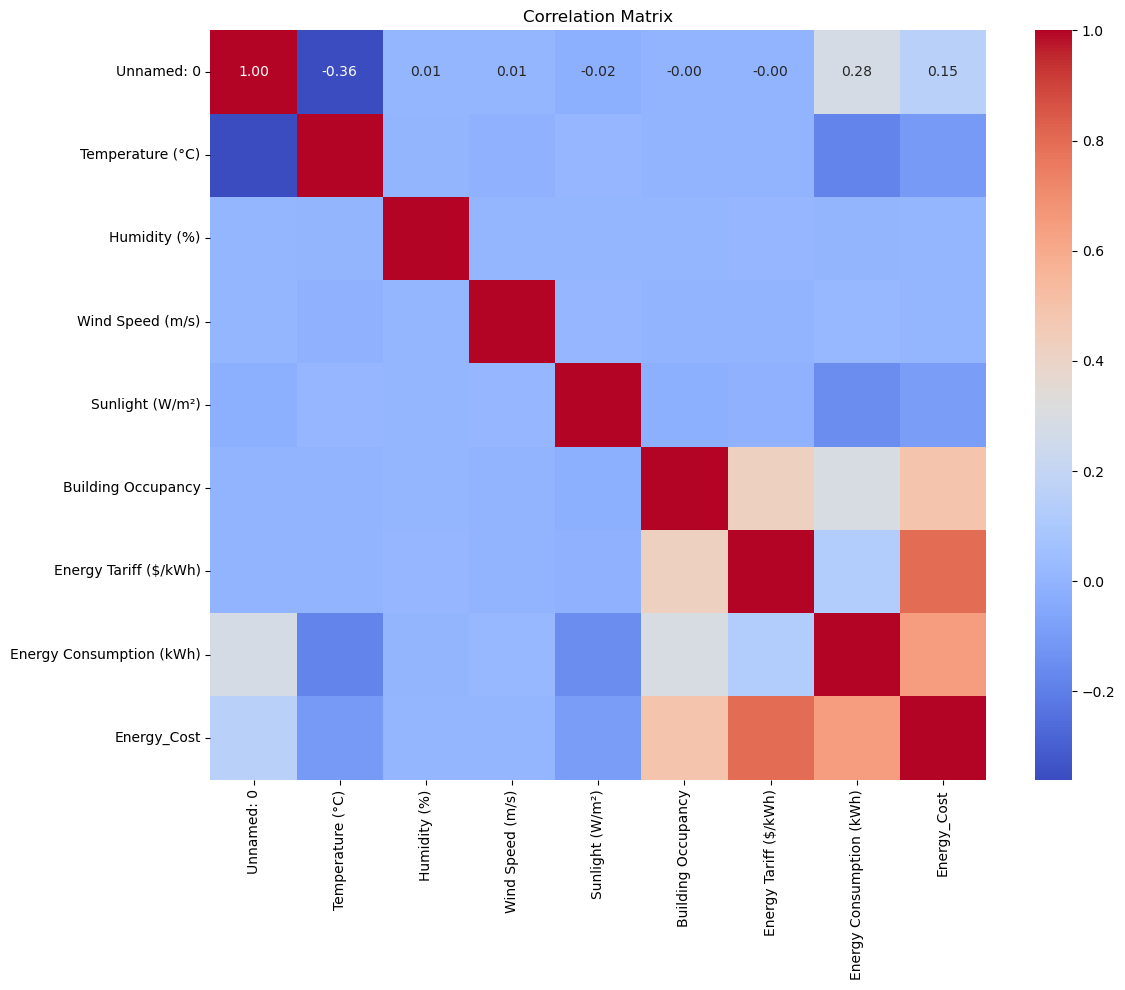

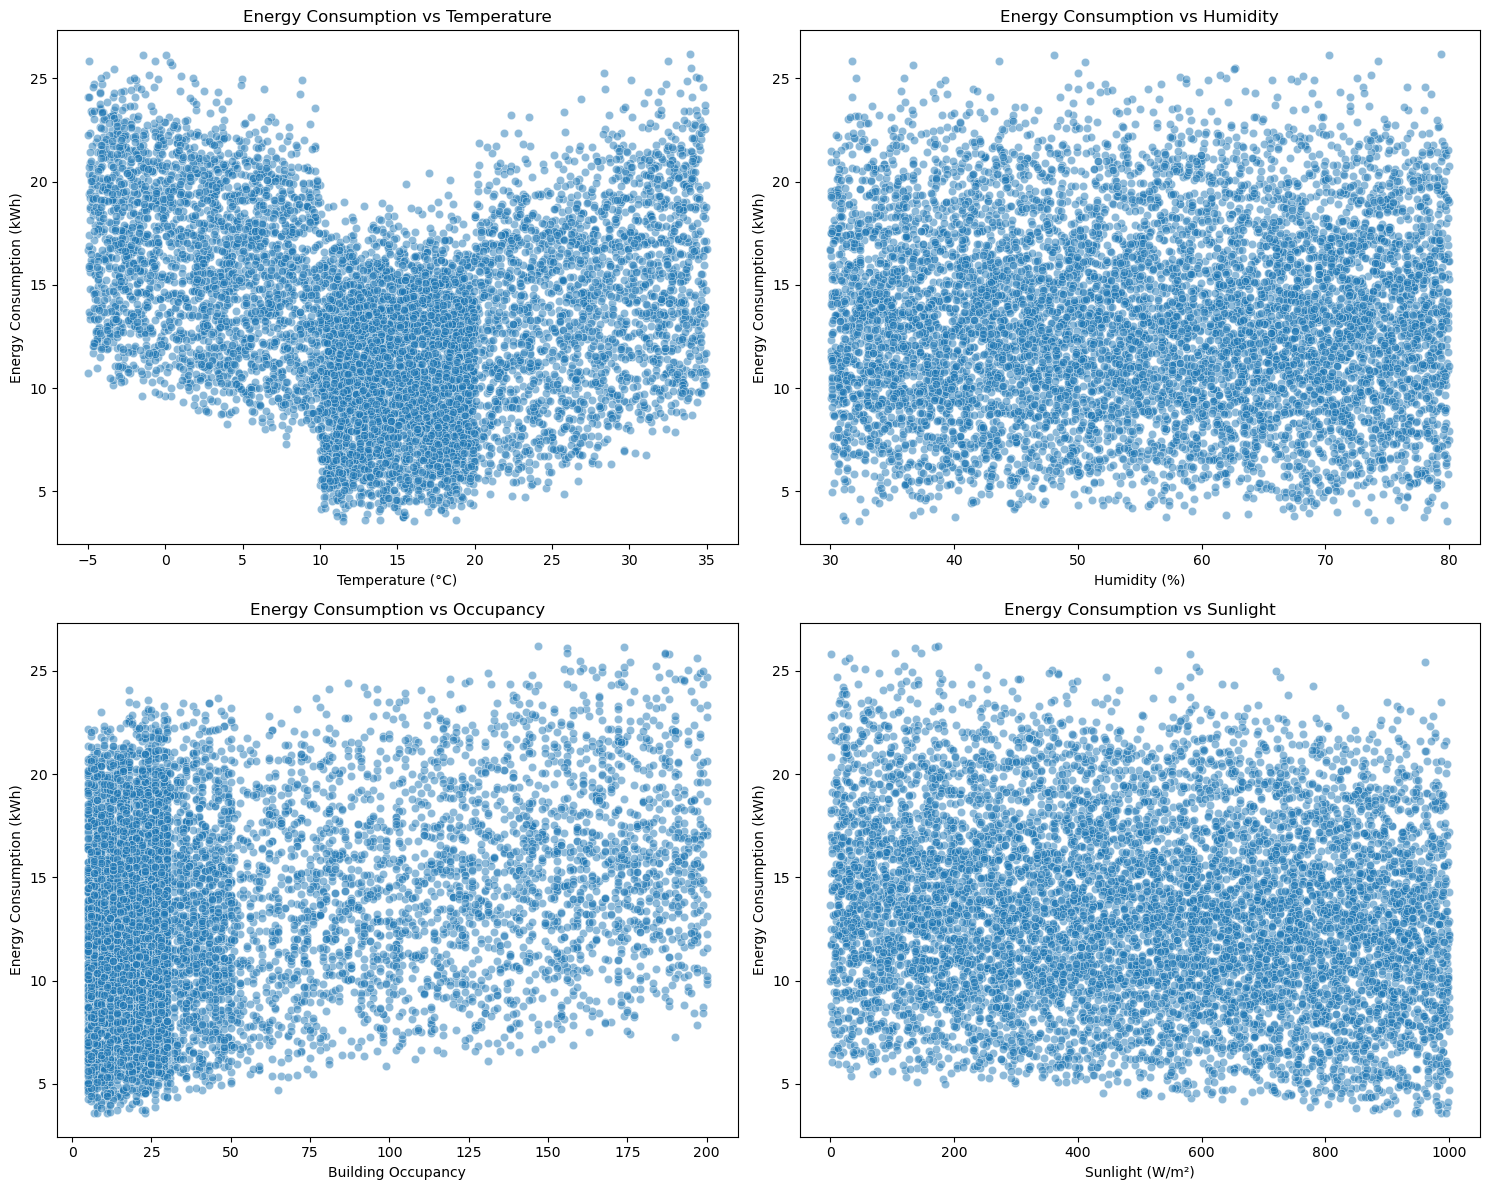

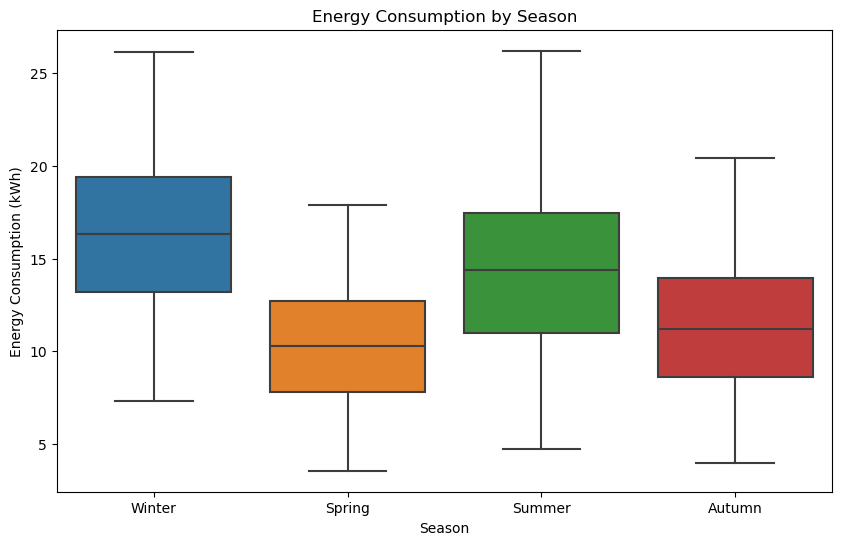

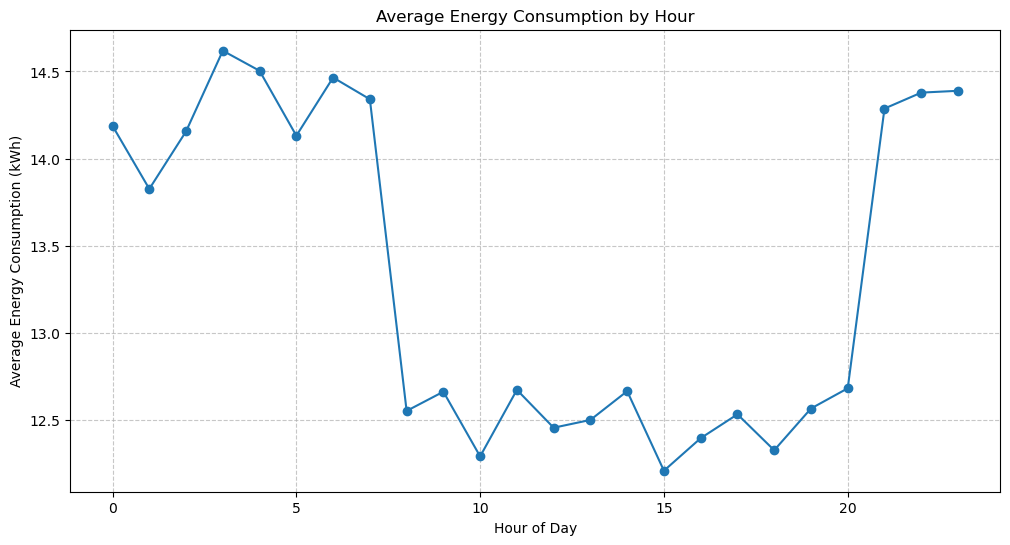

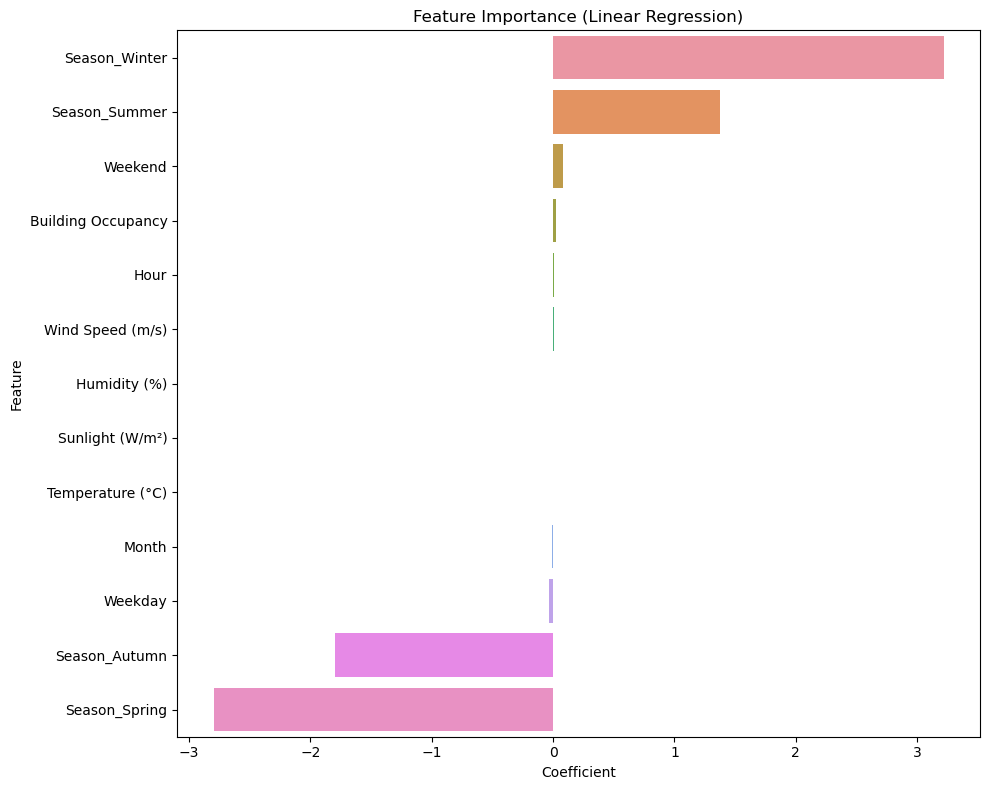

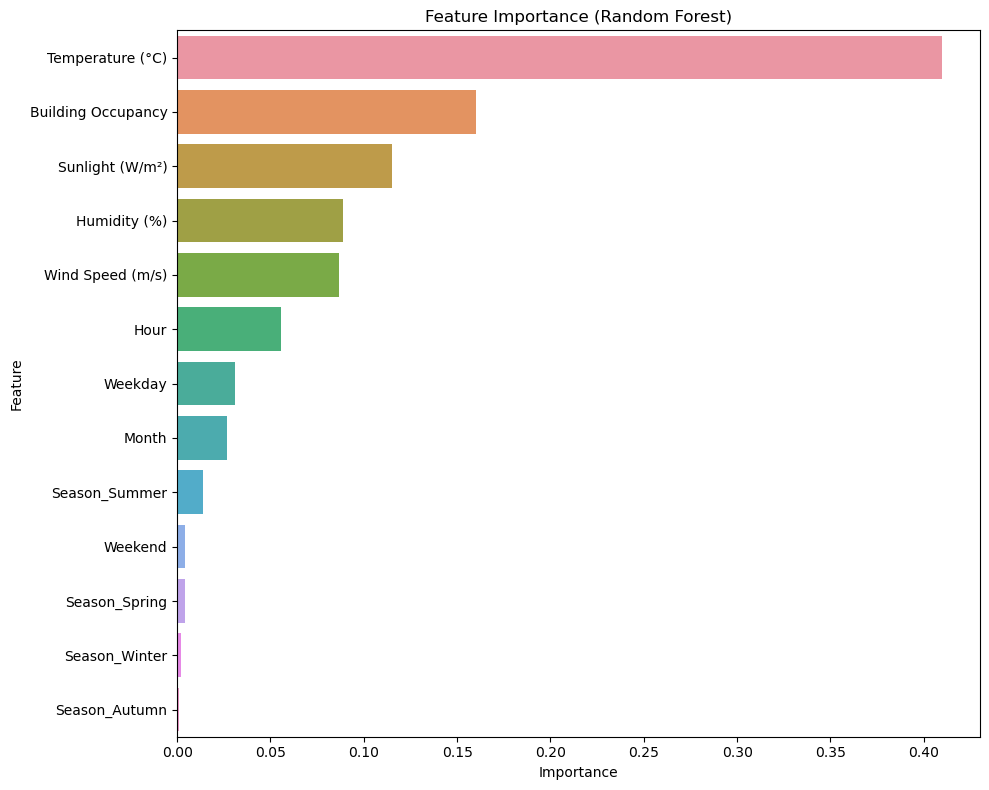

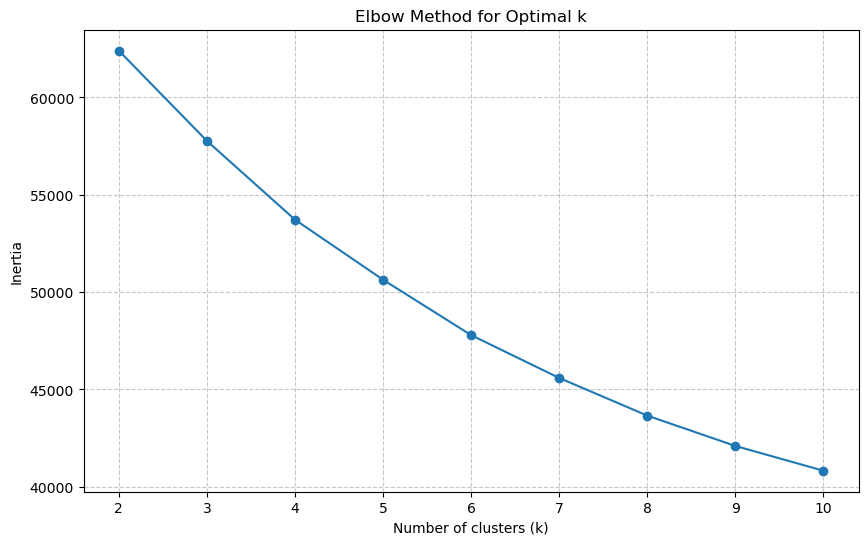

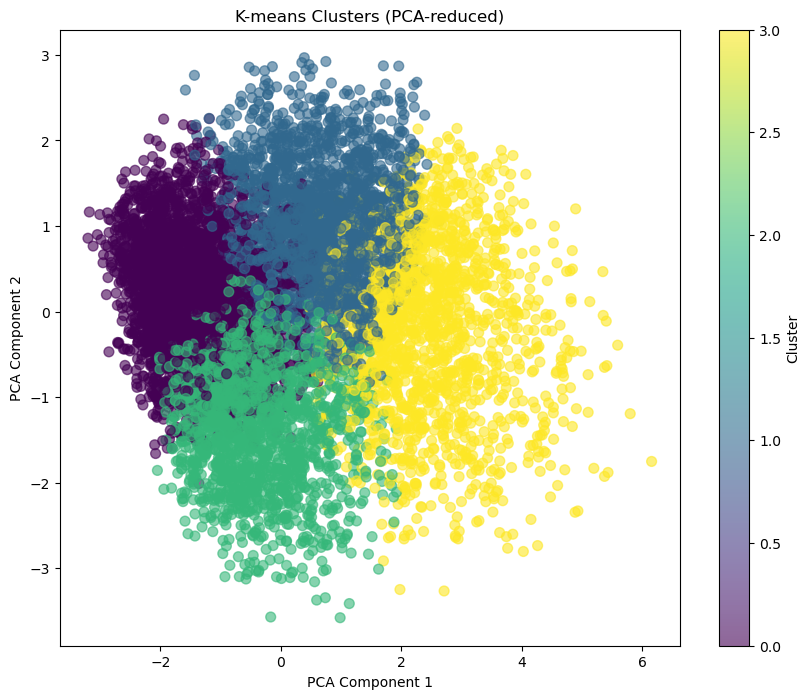

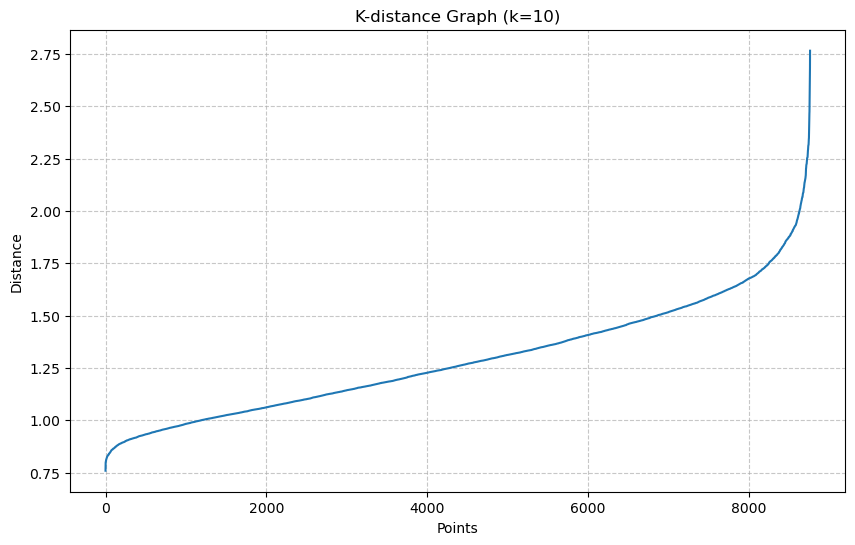

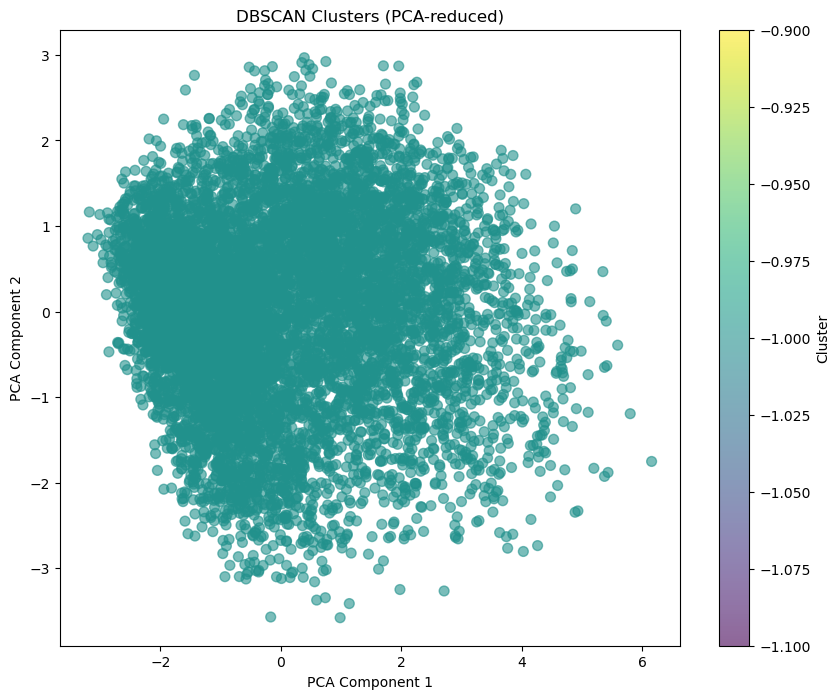

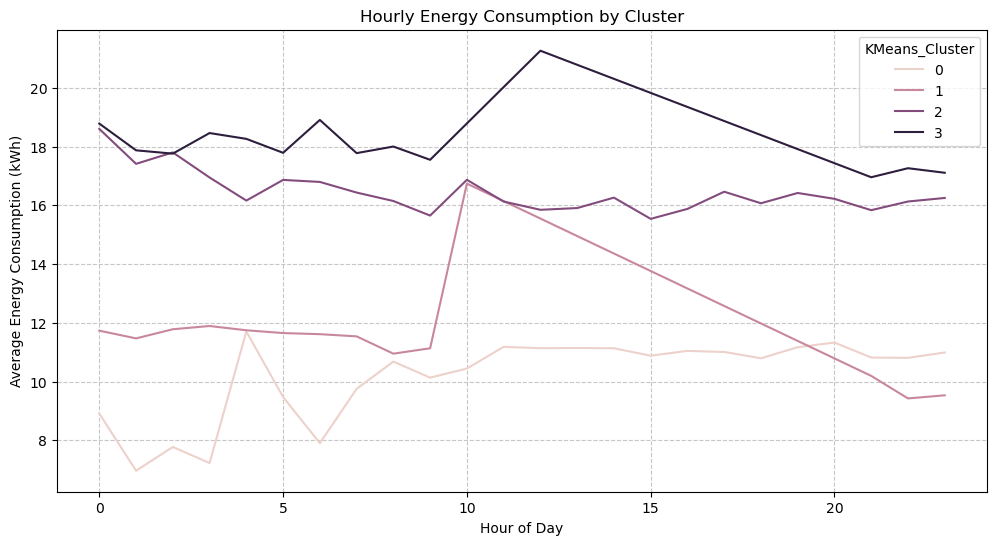

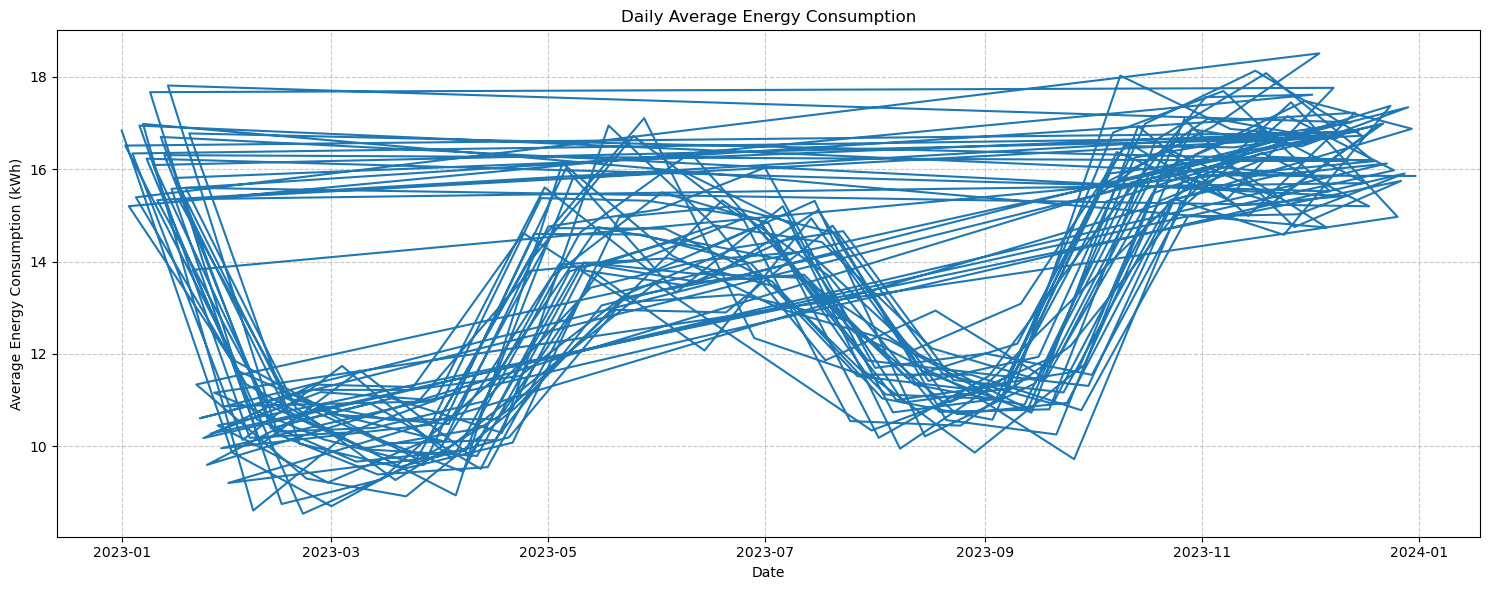

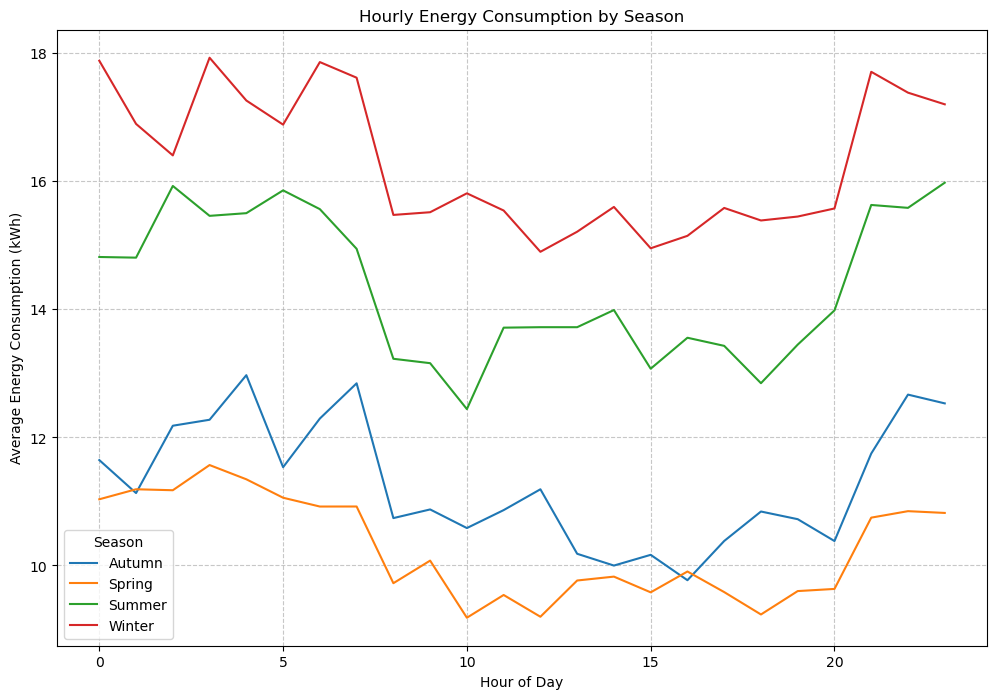

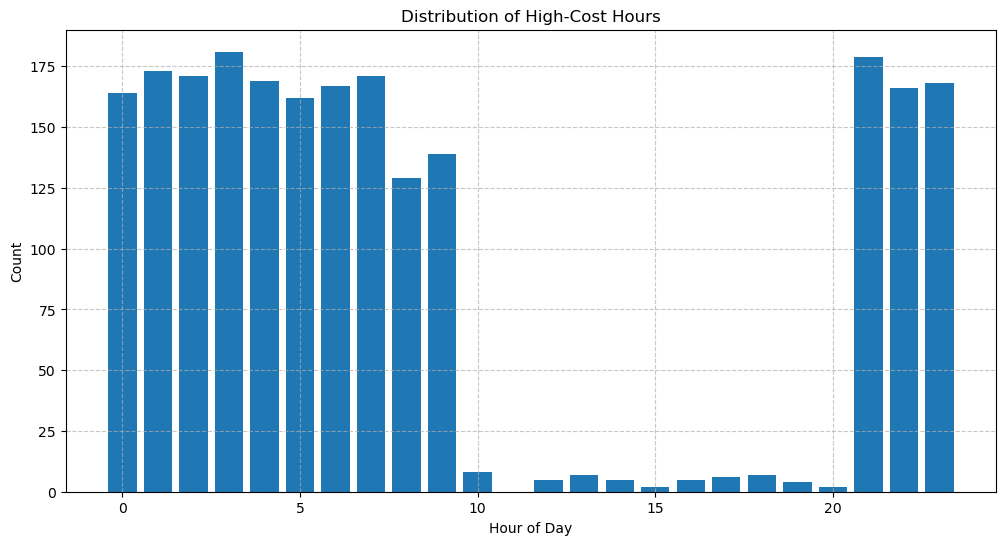

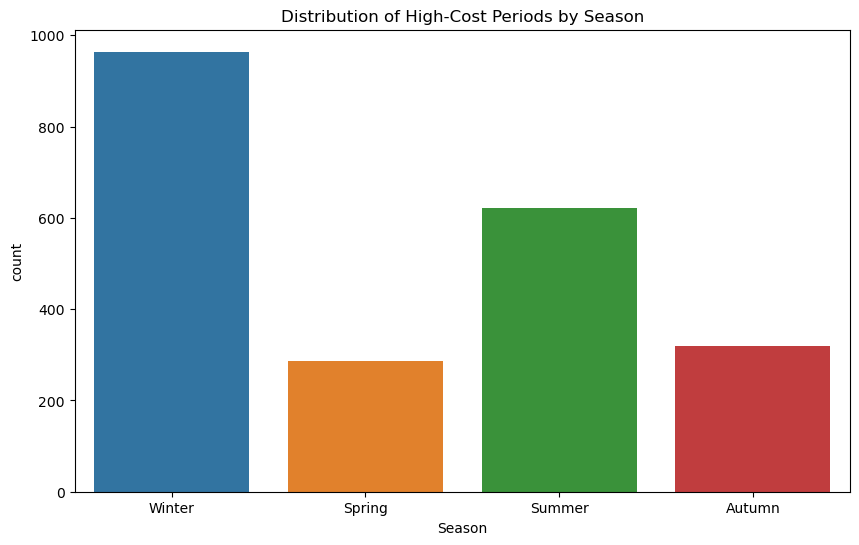

In [32]:
if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
import os

def load_and_prepare_data(file_path):
    """Load and prepare the dataset for modeling"""
    # Load the dataset
    df = pd.read_csv(file_path)
    
    # Convert timestamp to datetime
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    
    # Extract time-based features
    df['Hour'] = df['Timestamp'].dt.hour
    df['Day'] = df['Timestamp'].dt.day
    df['Month'] = df['Timestamp'].dt.month
    df['Weekday'] = df['Timestamp'].dt.weekday
    df['Weekend'] = df['Weekday'].isin([5, 6]).astype(int)
    
    # Calculate energy cost
    df['Energy_Cost'] = df['Energy Consumption (kWh)'] * df['Energy Tariff ($/kWh)']
    
    return df

def create_and_save_models(df, output_dir='saved_models'):
    """Create, train and save models for later use in DRF"""
    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
    
    # Prepare data for regression
    # Features and target
    features = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 
                'Sunlight (W/m²)', 'Building Occupancy', 'Hour', 'Weekday', 'Weekend', 'Month']
    
    # Handle categorical Season if present
    if 'Season' in df.columns:
        if df['Season'].dtype == 'object':
            # One-hot encode Season
            season_dummies = pd.get_dummies(df['Season'], prefix='Season')
            df = pd.concat([df, season_dummies], axis=1)
            # Add season columns to features
            season_cols = season_dummies.columns.tolist()
            features.extend(season_cols)
    
    X = df[features]
    y = df['Energy Consumption (kWh)']
    
    # Save feature list for reference in DRF
    joblib.dump(features, os.path.join(output_dir, 'feature_list.pkl'))
    print(f"Saved feature list to {os.path.join(output_dir, 'feature_list.pkl')}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Create and save preprocessor
    numeric_features = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 
                       'Sunlight (W/m²)', 'Building Occupancy', 'Hour', 'Month', 'Weekday']
    categorical_features = [col for col in features if col.startswith('Season_')]
    
    # Create preprocessor with scaling for numeric features
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', 'passthrough', categorical_features)
        ])
    
    # Fit and save preprocessor
    preprocessor.fit(X_train)
    joblib.dump(preprocessor, os.path.join(output_dir, 'preprocessor.pkl'))
    print(f"Saved preprocessor to {os.path.join(output_dir, 'preprocessor.pkl')}")
    
    # Create, train and save Linear Regression model
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    joblib.dump(lr_model, os.path.join(output_dir, 'linear_regression_model.pkl'))
    print(f"Saved Linear Regression model to {os.path.join(output_dir, 'linear_regression_model.pkl')}")
    
    # Create, train and save Random Forest model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, os.path.join(output_dir, 'random_forest_model.pkl'))
    print(f"Saved Random Forest model to {os.path.join(output_dir, 'random_forest_model.pkl')}")
    
    # Create, train and save K-means clustering model
    # Prepare data for clustering
    cluster_features = ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 
                       'Sunlight (W/m²)', 'Building Occupancy', 'Energy Tariff ($/kWh)', 
                       'Energy Consumption (kWh)', 'Hour']
    
    cluster_data = df[cluster_features].copy()
    
    # Scale the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(cluster_data)
    
    # Save scaler for clustering
    joblib.dump(scaler, os.path.join(output_dir, 'cluster_scaler.pkl'))
    print(f"Saved cluster scaler to {os.path.join(output_dir, 'cluster_scaler.pkl')}")
    
    # Save cluster features list
    joblib.dump(cluster_features, os.path.join(output_dir, 'cluster_features.pkl'))
    print(f"Saved cluster features to {os.path.join(output_dir, 'cluster_features.pkl')}")
    
    # K-means with 4 clusters (you may want to determine optimal k)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    joblib.dump(kmeans, os.path.join(output_dir, 'kmeans_model.pkl'))
    print(f"Saved K-means model to {os.path.join(output_dir, 'kmeans_model.pkl')}")
    
    # DBSCAN clustering
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    dbscan.fit(scaled_data)
    joblib.dump(dbscan, os.path.join(output_dir, 'dbscan_model.pkl'))
    print(f"Saved DBSCAN model to {os.path.join(output_dir, 'dbscan_model.pkl')}")
    
    # Create a metadata file with model information
    metadata = {
        'regression_features': features,
        'clustering_features': cluster_features,
        'models': {
            'linear_regression': 'linear_regression_model.pkl',
            'random_forest': 'random_forest_model.pkl',
            'kmeans': 'kmeans_model.pkl',
            'dbscan': 'dbscan_model.pkl'
        },
        'preprocessors': {
            'main_preprocessor': 'preprocessor.pkl',
            'cluster_scaler': 'cluster_scaler.pkl'
        },
        'target': 'Energy Consumption (kWh)'
    }
    
    # Save metadata as JSON
    import json
    with open(os.path.join(output_dir, 'model_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=4)
    
    print(f"Saved model metadata to {os.path.join(output_dir, 'model_metadata.json')}")
    
    return {
        'linear_regression': lr_model,
        'random_forest': rf_model,
        'kmeans': kmeans,
        'dbscan': dbscan,
        'preprocessor': preprocessor,
        'cluster_scaler': scaler
    }

def main():
    # In a real scenario, replace this with your actual file path
    file_path = r"C:\Users\91995\OneDrive\Desktop\Sustainathon\DataSets\Updated_Environmental & External Factors.csv"
    
    try:
        print("Loading data...")
        df = load_and_prepare_data(file_path)
        print("Data loaded successfully!")
        
        print("\nTraining and saving models...")
        models = create_and_save_models(df)
        print("\nAll models successfully trained and saved!")
        
        print("\nModels are ready for use in Django REST Framework.")
    except FileNotFoundError:
        print(f"Error: File {file_path} not found.")
        print("Please provide the correct path to your data file.")
    except Exception as e:
        print(f"An error occurred: {str(e)}")

if __name__ == "__main__":
    main()